In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import sys
sys.path.append('..')
from src.mcculloch_pitts import McCullochPittsNeuron


In [52]:
and_neuron = McCullochPittsNeuron(n_inputs=2, threshold=2)
and_table = and_neuron.truth_table()
print("\nAND Truth Table:")
print("x1  x2  |  output")
print("-" * 20)
for inp, out in zip(and_table['inputs'], and_table['outputs']):
    print(f" {inp[0]}   {inp[1]}  |    {out}")


AND Truth Table:
x1  x2  |  output
--------------------
 0   0  |    0
 0   1  |    0
 1   0  |    0
 1   1  |    1


In [25]:
or_neuron = McCullochPittsNeuron(n_inputs=2, threshold=1)
or_table = or_neuron.truth_table()

print("\nOR Truth Table:")
print("x1  x2  |  output")
print("-" * 20)
for inp, out in zip(or_table['inputs'], or_table['outputs']):
    print(f" {inp[0]}   {inp[1]}  |    {out}")



OR Truth Table:
x1  x2  |  output
--------------------
 0   0  |    0
 0   1  |    1
 1   0  |    1
 1   1  |    1


In [53]:
xor_expected = np.array([0, 1, 1, 0])
test_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

print("\nExpected XOR output: [0, 1, 1, 0]")
print("\nTesting different thresholds:\n")

thresholds_to_test = [0, 0.5, 1, 1.5, 2, 2.5]
xor_possible = False

for thresh in thresholds_to_test:
    neuron = McCullochPittsNeuron(n_inputs=2, threshold=thresh)
    outputs = neuron.forward(test_inputs)
    match = np.array_equal(outputs, xor_expected)
    
    print(f"Threshold = {thresh:.1f} → Output: {outputs} {'Match!' if match else 'No match'}")

print("XOR is impossible with McCulloch-Pitts neuron")



Expected XOR output: [0, 1, 1, 0]

Testing different thresholds:

Threshold = 0.0 → Output: [1 1 1 1] No match
Threshold = 0.5 → Output: [0 1 1 1] No match
Threshold = 1.0 → Output: [0 1 1 1] No match
Threshold = 1.5 → Output: [0 0 0 1] No match
Threshold = 2.0 → Output: [0 0 0 1] No match
Threshold = 2.5 → Output: [0 0 0 0] No match
XOR is impossible with McCulloch-Pitts neuron


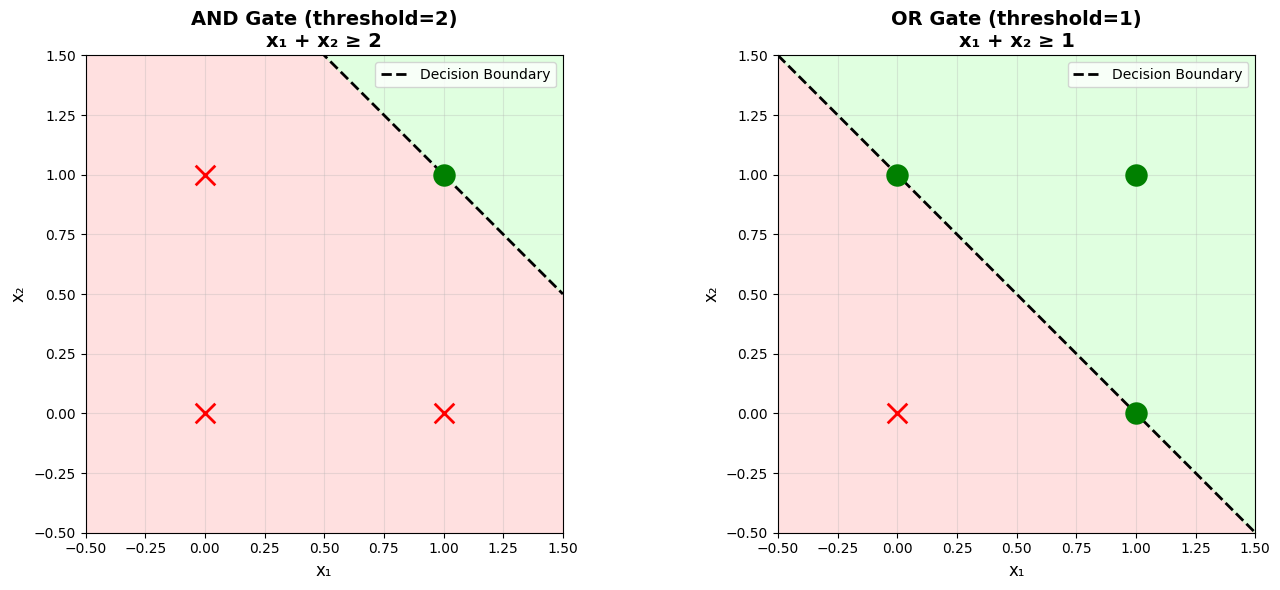

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_decision_boundary(ax, neuron, title):
    x1_range = np.linspace(-0.5, 1.5, 300)
    x2_range = np.linspace(-0.5, 1.5, 300)
    X1, X2 = np.meshgrid(x1_range, x2_range)
    
    grid_points = np.c_[X1.ravel(), X2.ravel()]
    Z = neuron.forward(grid_points)
    Z = Z.reshape(X1.shape)
    
    ax.contourf(X1, X2, Z, levels=[0, 0.5, 1], colors=['#ffcccc', '#ccffcc'], alpha=0.6)
    
    threshold_line_x = np.linspace(-0.5, 1.5, 100)
    threshold_line_y = neuron.threshold - threshold_line_x
    ax.plot(threshold_line_x, threshold_line_y, 'k--', linewidth=2, label='Decision Boundary')
    
    truth_table = neuron.truth_table()
    inputs = truth_table['inputs']
    outputs = truth_table['outputs']
    
    for inp, out in zip(inputs, outputs):
        color = 'green' if out == 1 else 'red'
        marker = 'o' if out == 1 else 'x'
        size = 200
        ax.scatter(inp[0], inp[1], c=color, marker=marker, s=size, 
                  linewidths=2, zorder=5)
    
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xlabel('x₁', fontsize=12)
    ax.set_ylabel('x₂', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_aspect('equal')

plot_decision_boundary(axes[0], and_neuron, 'AND Gate (threshold=2)\nx₁ + x₂ ≥ 2')
plot_decision_boundary(axes[1], or_neuron, 'OR Gate (threshold=1)\nx₁ + x₂ ≥ 1')
plt.tight_layout()


There's no way we can separate both class with one straight line


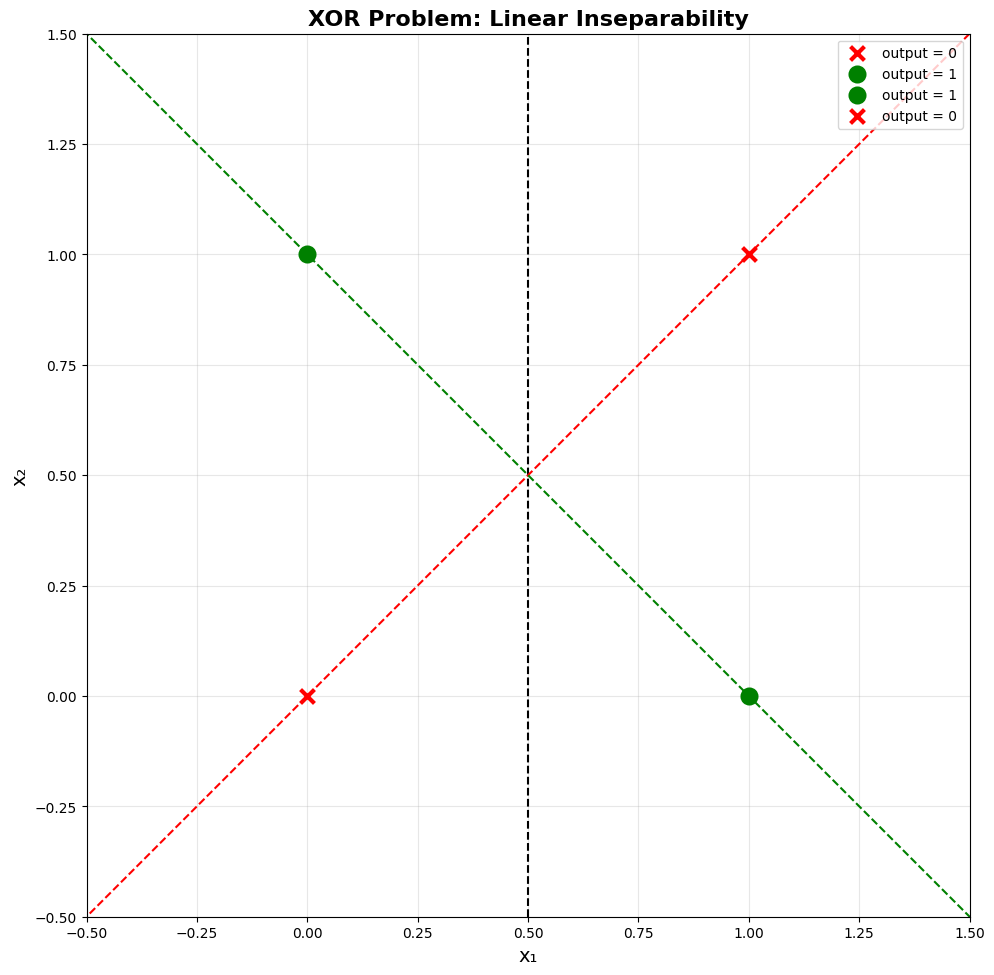

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
xor_inputs = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_outputs = np.array([0, 1, 1, 0])
for inp, out in zip(xor_inputs, xor_outputs):
    color = 'green' if out == 1 else 'red'
    marker = 'o' if out == 1 else 'x'
    label = 'output = 1' if out == 1 else 'output = 0'
    size = 100
    ax.scatter(inp[0], inp[1], c=color, marker=marker, s=size, label=label,
              linewidths=3, zorder=5)
ax.axvline(x=0.5, linestyle='--', c='black')
ax.plot(np.linspace(-1,2,10), np.linspace(-1,2,10), linestyle='--', c='red')
ax.plot(np.linspace(-1,2,10), -np.linspace(-1,2,10)+1, linestyle='--', c='green')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_xlabel('x₁', fontsize=14)
ax.set_ylabel('x₂', fontsize=14)
ax.set_title('XOR Problem: Linear Inseparability', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
print("There's no way we can separate both class with one straight line")
plt.show()